## Analysis on Play Store Review

### Import Libraries, Declare Trivial Options

In [49]:
import kagglehub
import os
import numpy as np
import cupy as cp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import altair as alt

from scipy.stats import yeojohnson, zscore
from sklearn.feature_extraction.text import TfidfVectorizer
from cuml.cluster import KMeans
from dask_ml.cluster import SpectralClustering

from util import to_darr
from calc import get_svd, cluster_iterated, cluster_aggregated

sns.set_theme(
  style='white', 
  font_scale=.7,
  palette='Set2',
  font='Monospace'
)

asthetic_constraint=dict(
  alpha=.9,
)

pyarrow_constraint=dict(
  compression='zstd',
  compression_level=9
)


## Sanitise the Dataset

### Download

In [50]:
# Or, path=kagglehub.dataset_download("shivkumarganesh/tinder-google-play-store-review")
path='/home/yuninze/.cache/kagglehub/datasets/shivkumarganesh/tinder-google-play-store-review/versions/158'

os.chdir(path)

data=pd.read_csv(os.path.join(path, os.listdir()[0]))

data.info(1)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 641303 entries, 0 to 641302
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   reviewId              641303 non-null  object
 1   userName              641303 non-null  object
 2   userImage             641303 non-null  object
 3   content               639970 non-null  object
 4   score                 641303 non-null  int64 
 5   thumbsUpCount         641303 non-null  int64 
 6   reviewCreatedVersion  509929 non-null  object
 7   at                    641303 non-null  object
 8   replyContent          59332 non-null   object
 9   repliedAt             59332 non-null   object
 10  appVersion            509929 non-null  object
dtypes: int64(2), object(9)
memory usage: 53.8+ MB


In [51]:
data.sample(3)

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
404294,37141522-9020-4ce6-a183-8822c147a696,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Does exactly what it says. Shame it's so expen...,5,1,8.10.4,2018-04-06 03:50:25,NaN,NaN,8.10.4
272934,7da14929-63d1-4ac7-97dd-179c4a5e9fec,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Installetion problem.,1,0,NaN,2019-12-10 10:55:18,NaN,NaN,NaN
233908,b85a3e6a-147b-4f11-bf66-9cd13663e95c,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Its cool to meet ppl,5,0,11.19.0,2020-07-12 01:16:22,NaN,NaN,11.19.0


### Remove Unnecessary Columns

In [52]:
data.index.size == data.reviewId.nunique()

True

In [53]:
data=data.iloc[:,[0,3,4,5,7,10]].copy()
data.sample(3)

,reviewId,content,score,thumbsUpCount,at,appVersion
620749,5ceaa95a-f9de-43ce-b977-4863627decc2,"Eventhough I search girls , some boys show.",1,0,2014-06-03 21:22:22,2.2.3
392362,ea3eb16e-95e2-4e2f-9a86-b5d14b231bc1,love it got 22 matches,5,0,2018-06-21 09:40:24,NaN
634179,6a40f613-87f6-45e4-b271-45d4f703b263,Very easy to use and much greater quality of m...,4,0,2013-12-15 06:34:00,2.1.0


In [54]:
data=data.drop('reviewId', axis=1)
data.sample(3)

,content,score,thumbsUpCount,at,appVersion
589633,I don't see why you can only use Facebook to s...,1,1,2015-02-22 15:36:25,4.0.4
118798,I can't see who likes me even with gold pass W...,1,0,2022-07-25 00:23:56,13.12.0
213164,3rd time this app went crash happy.,1,1,2020-11-10 11:35:51,11.27.0


In [55]:
data_processed_some=pd.DataFrame(dict(
  thumb=data.thumbsUpCount,
  star=data.score,
  review=data.content,
  ver=data.appVersion
))
data_processed_some.sample(3)

,thumb,star,review,ver
148622,0,5,Good,NaN
378174,0,2,I've had the tinder glitch several times. Upse...,9.10.0
344957,0,5,just awesome,10.6.0


### Parse Datetime Values

In [56]:
_at=pd.to_datetime(data['at']).round('1h')
_at.to_frame().sample(3)

,at
45101,2023-12-25 18:00:00
186949,2021-04-15 09:00:00
276134,2019-11-21 01:00:00


In [57]:
data_dt=pd.DataFrame(dict(
  at=_at,
  atYear=_at.dt.year,
  atMonth=_at.dt.month,
  atHourInterval=_at.dt.hour,
  atDay=_at.dt.dayofweek,
  atQuarter=list(
    map(lambda q: f'Q{int((q-1) / 3) + 1}', _at.dt.month)
  )
))
zip(np.unique(data_dt.atQuarter.to_numpy(dtype='U2'),return_counts=True))
data_dt.sample(3)

,at,atYear,atMonth,atHourInterval,atDay,atQuarter
101832,2022-11-21 06:00:00,2022,11,6,0,Q4
618584,2014-06-20 04:00:00,2014,6,4,4,Q2
431821,2017-10-18 07:00:00,2017,10,7,2,Q4


### Remove Rows without Review

In [58]:
data_processed=pd.concat([
  data_processed_some,
  data_dt
],axis=1).dropna(subset='review').sort_values('atYear')
data_processed.sample(3)

,thumb,star,review,ver,at,atYear,atMonth,atHourInterval,atDay,atQuarter
494521,0,5,I like it i am barely trying out dating apps a...,6.0.3,2016-10-15 13:00:00,2016,10,13,5,Q4
499988,0,5,Really great app,5.4.1,2016-09-11 04:00:00,2016,9,4,6,Q3
116605,0,1,Whatever the newest update did destroyed it. D...,13.13.0,2022-08-08 14:00:00,2022,8,14,0,Q3


### Interpolate Version by Date

In [59]:
data_processed.isna().sum()

thumb                  0
star                   0
review                 0
ver               131299
at                     0
atYear                 0
atMonth                0
atHourInterval         0
atDay                  0
atQuarter              0
dtype: int64

In [60]:
_ver_interp=pd.DataFrame(
  dict(
    ind=data_processed.index,
    ver=data_processed.ver.to_list()
  ),
  index=data_processed['at']
)
_ver_interp.ver[data_processed.ver.isna().to_list()].sample(3)

at
2020-12-10 09:00:00    NaN
2020-10-04 03:00:00    NaN
2023-11-19 03:00:00    NaN
Name: ver, dtype: object

In [61]:
_ver_interp.interpolate('pad')[data_processed.ver.isna().to_list()].sample(3)

,ind,ver
at,,
2019-07-17 10:00:00,302483,10.18.0
2022-03-12 07:00:00,138343,13.2.0
2021-11-14 14:00:00,155394,11.0.1


In [62]:
_ver_interp=_ver_interp.interpolate('pad')
data_processed.loc[:, 'ver']=_ver_interp.ver.to_list()
data_processed.ver.isna().sum()

0

## Analysis

### Review Intensity (Count) by Year

* 2018 - 2019 seems to the most positive period (highest number of 5 star reviews) for the app.
  * This is likely due to huge user inflow by early stage of lockdown, and service industry breakdown.
* Number of 5 star reviews shows clear downtrend since major declaration of lockdown from March 2020.
  * Intrinsic reasons, such as changes of business logic, or algorithm (e.g. app version) is likely an issue.

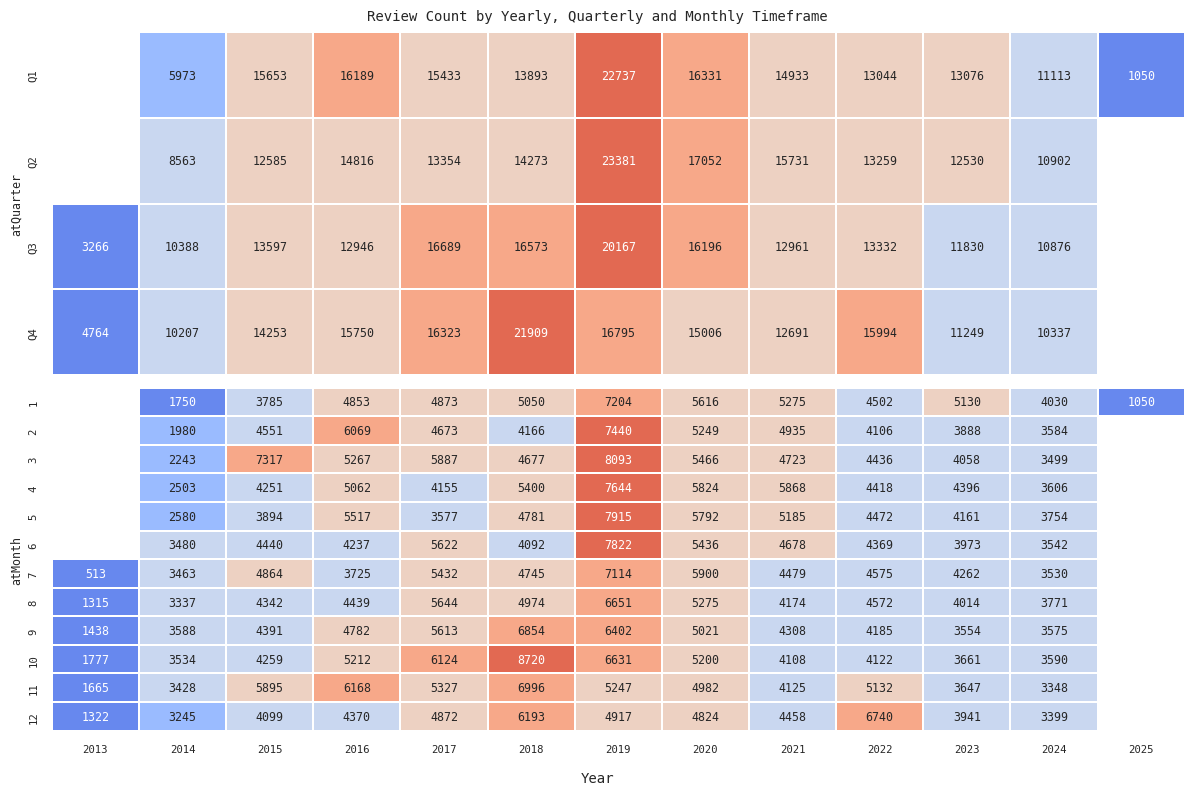

In [63]:
fig,ax=plt.subplots(2,1,figsize=(12,8))

above=sns.heatmap(
  data_processed.groupby(['atQuarter','atYear']).star.size().reset_index().pivot(
    index='atQuarter',columns='atYear',values='star'
  ),
  annot=True,
  cmap=sns.color_palette('coolwarm'),
  linewidth=.1,
  cbar=False,
  fmt='.0f',
  ax=ax[0]
)

below=sns.heatmap(
  data_processed.groupby(['atMonth','atYear']).star.size().reset_index().pivot(
    index='atMonth',columns='atYear',values='star'
  ),
  annot=True,
  cmap=sns.color_palette('coolwarm'),
  linewidth=.1,
  cbar=False,
  fmt='.0f',
  ax=ax[1]
)

above.set_xticks([])
[q.set_xlabel('') for q in (above,below)]
fig.suptitle('Review Count by Yearly, Quarterly and Monthly Timeframe')
fig.supxlabel('Year')
fig.tight_layout()

Text(0.5, 1.0, 'Yearly Count by Mean of Star')

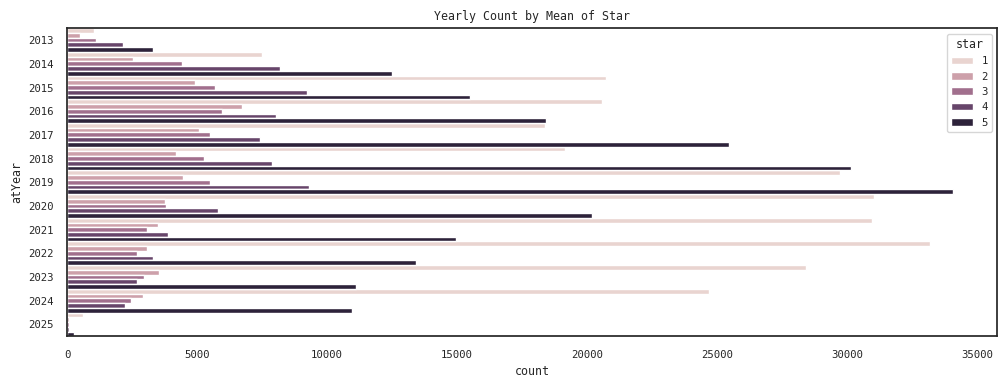

In [64]:
plt.subplots(figsize=(12,4))
star_mean_count_yearly=sns.countplot(data_processed, y='atYear', hue='star', dodge=True, width=1.)
star_mean_count_yearly.set_title('Yearly Count by Mean of Star')

#### Hourly, Quarterly Number of App Rating (Stars)

* There seems to a no quarterly seasonality.
  * Average rating is more likely to be affected by other reasons like algorithm changes, and imbalance of user proportion by massive inflow.
* The users are tend to give bad reviews at the late night, and they're giving good reviews at the morning.
  * It's not hard to assuming the user could encounter unpleasant events at the night, but it's strange that anybody wrote positive reviews at the morning.

In [65]:
data_processed_star=data_processed.query('atYear not in (2013, 2025)').groupby(['atYear','atQuarter','atHourInterval']).star.mean().round(3).reset_index()
data_processed_star.sample(3)

,atYear,atQuarter,atHourInterval,star
721,2021,Q3,1,2.303
259,2016,Q3,19,2.736
978,2024,Q1,18,2.306


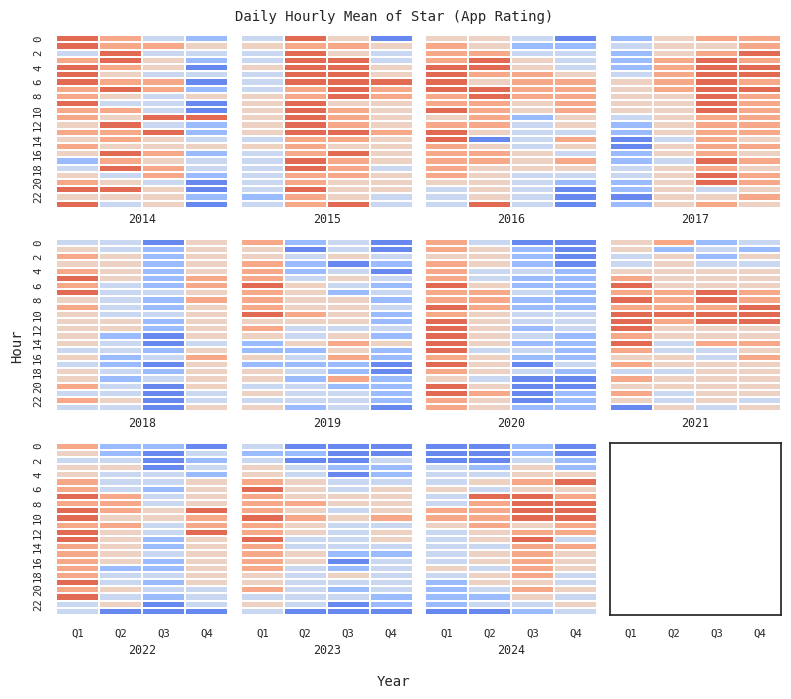

In [66]:
fig,ax=plt.subplots(3,4,sharex=True,sharey=True,figsize=(8,7))

for obj_year in zip(ax.flat,data_processed_star.atYear.unique()):
  for obj_quarter in enumerate([f'q{w}' for w in range(1,5)]):
    hourly_star=sns.heatmap(
      data_processed_star.loc[data_processed_star.atYear==obj_year[1]].pivot(index='atHourInterval',columns='atQuarter',values='star'),
      cmap=sns.color_palette('coolwarm'),
      linewidth=.1,
      cbar=False,
      ax=obj_year[0]
    )
    hourly_star.set_xlabel(f'{obj_year[1]}')
    hourly_star.set_ylabel('')

fig.supxlabel('Year')
fig.supylabel('Hour')
fig.suptitle('Daily Hourly Mean of Star (App Rating)')
fig.tight_layout()


/tmp/ipykernel_44539/800033385.py:4: FutureWarning: This dataframe has a column name that matches the 'value_name' column name of the resulting Dataframe. In the future this will raise an error, please set the 'value_name' parameter of DataFrame.melt to a unique name.
  data_processed.melt(


Text(0.5, 0.98, 'Stars By Timeframe')

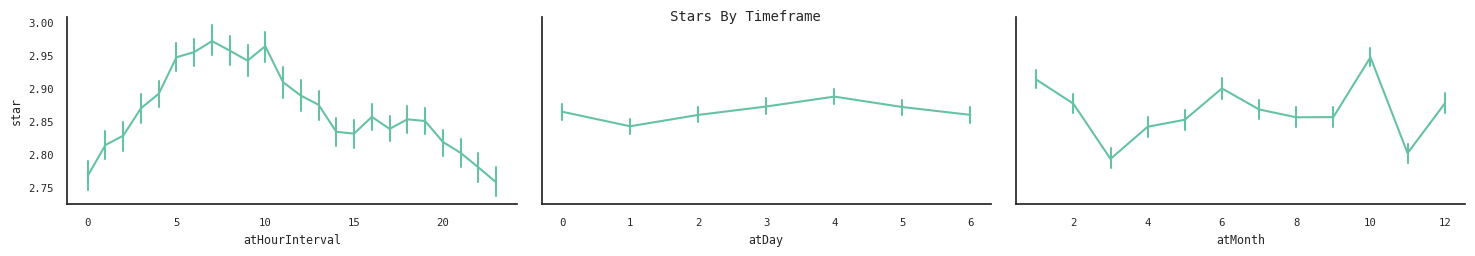

In [67]:
timeframe_list=['atHourInterval', 'atDay', 'atMonth']

star_by_timeframe=sns.PairGrid(
  data_processed.melt(
    timeframe_list,
    'star',
    var_name='Timeframe',
    value_name='star'
  ),
  x_vars=timeframe_list,
  y_vars=['star'],
  aspect=2
)

star_by_timeframe.map(sns.lineplot,err_style='bars')

star_by_timeframe.fig.suptitle('Stars By Timeframe')

In [68]:
star_monthly_daily=data_processed.loc[:, ['atMonth', 'atDay', 'star']]
star_monthly_daily.columns=['Month','Day','Star']
star_monthly_daily=star_monthly_daily.groupby(['Month', 'Day']).Star.mean()
star_monthly_daily.index=star_monthly_daily.index.set_levels(
  star_monthly_daily.index.get_level_values(level=1).map(
  lambda q: {
    0: 'Mon',
    1: 'Tue',
    2: 'Wed',
    3: 'Thu',
    4: 'Fri',
    5: 'Sat',
    6: 'Sun'
  }[q]
  ),level=1,verify_integrity=False)

Text(0.5, 1.0, 'Mean Star Rating by Monthly Day')

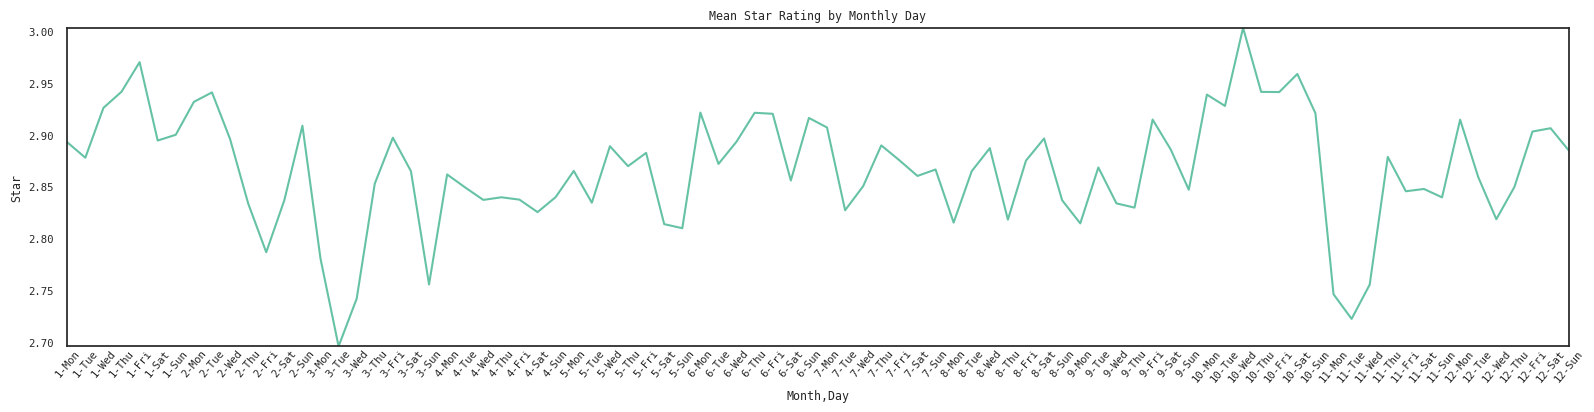

In [69]:
fig,ax=plt.subplots(figsize=(16,4))
star_monthly_daily.plot(ax=ax)
ax.set_xticks(
  range(len(star_monthly_daily.index)),
  [f'{q[0]}-{q[1]}' for q in star_monthly_daily.index],
  rotation=50
)
ax.tick_params(axis='x', pad=-5)
ax.set_ylabel('Star')

plt.margins(0)
plt.tight_layout()

ax.set_title('Mean Star Rating by Monthly Day')

### Score Star (Review Ratings)

* It's well known that there's a 'featured review' with an usefulness score on Play Store, to giving higher order for certain reviews.
  * I will take account both thumbs and stars are generating an usefulness score.
* The scatter shows uptrending variance since post-lockdown (roughly in 2020)
  * Since the downtrend, the users are aligned with bad sentiment towards to the app in Q4.
    * This is likely that the trend is related to both extrinsic and intrinsic problems.

In [125]:
data_processed=pd.read_feather('/home/yuninze/res/gps-review.feather')

In [127]:
data_processed=data_processed.assign(score=(
  yeojohnson((data_processed.thumb+1) * (data_processed.star - 2.5))[0]
))
data_processed.groupby('star').score.describe().T

star,1,2,3,4,5
count,265961.000000,45157.000000,48422.000000,70112.000000,210318.000000
mean,-5.202151,-1.857598,1.525416,3.182238,3.565584
std,43.375537,13.718477,16.308869,49.309061,37.154271
min,-5222.748574,-929.314715,0.506146,1.545396,2.609002
25%,-2.860603,-0.493950,0.506146,1.545396,2.609002
50%,-1.456248,-0.493950,0.506146,1.545396,2.609002
75%,-1.456248,-0.493950,0.506146,1.545396,2.609002
max,-1.456248,-0.493950,1487.178908,9433.886318,11038.254672


(0.05, 0.05)

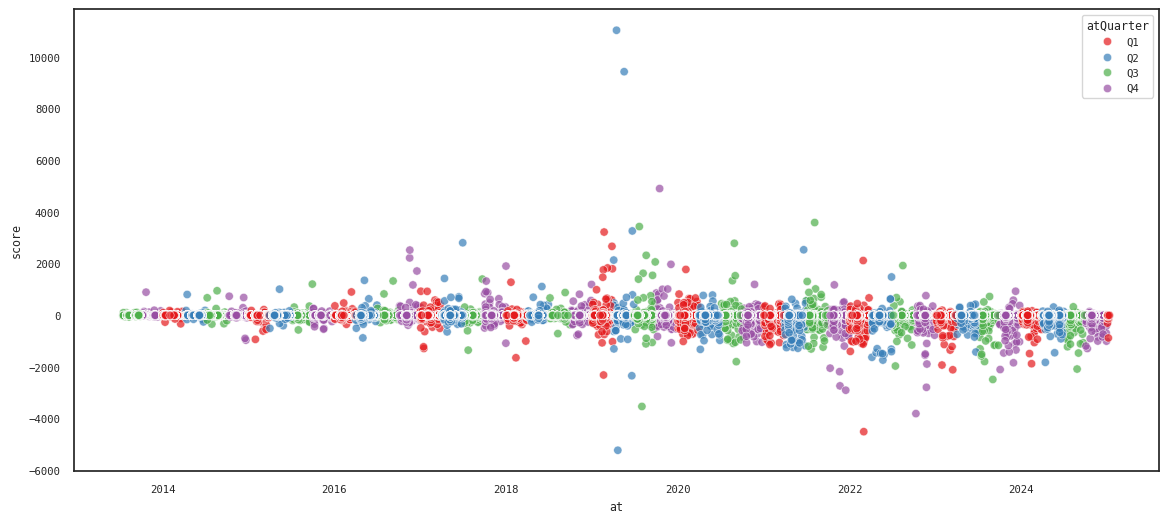

In [128]:
fig,ax=plt.subplots(figsize=(14,6))

sns.scatterplot(
  data=data_processed,
  x='at',
  y='score',
  hue='atQuarter',
  hue_order=['Q1','Q2','Q3','Q4'],
  palette=sns.color_palette('Set1', n_colors=4),
  alpha=.7,
  legend='brief',
  ax=ax
)

plt.margins(None)

# alt.Chart(data_processed).mark_circle(opacity=.8).encode(
#   alt.X('at',type='temporal').title('Timestamp'),
#   alt.Y('score',type='quantitative').title('Score (rating)'),
#   alt.Color('atQuarter',type='nominal').title('Quarter')).properties(width=500,height=500).show()


#### Aggregated App Rating by App Version, Year

* Below lineplots show clear downtrends after the major lockdown at March, 2020.
  * The sentiment may be related to vital problems at the time (e.g. increasing jobloss count and revenue discount rate). 
  * More can be known with further info beyond this dataset.

In [129]:
data_processed.loc[:, 'ver'] = data_processed.ver.apply(
  lambda q: q[:q.index('.')] if q.__contains__('.') else q
)
data_processed.sample(3)

,thumb,star,review,ver,at,atYear,atMonth,atHourInterval,atDay,atQuarter,score,reviewType,reviewTypeSpectral,reviewTypeSupervised
193126,0,1,Useless. Login doesn't work anymore. Tried eve...,6,2017-02-28 18:00:00,2017,2,18,1,Q1,-1.456248,4,1,0
167711,0,5,All the woman on here are super gorgeous makes...,7,2017-08-02 18:00:00,2017,8,18,2,Q3,2.609002,1,3,0
141764,0,1,Maybe the developers should be more extensive ...,4,2016-02-08 21:00:00,2016,2,21,0,Q1,-1.456248,4,3,0


Text(0.5, 0.98, 'Mean of Star, by App Version and Year')

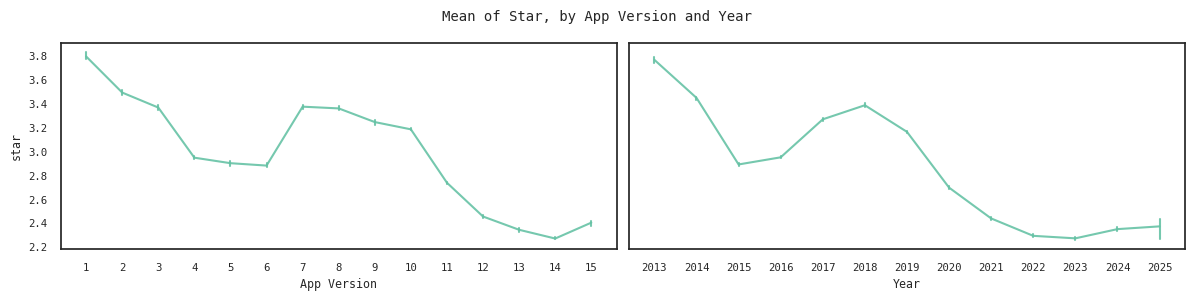

In [130]:
fig,ax=plt.subplots(1,2,figsize=(12,3),layout='tight',sharey=True)

star_by_ver=sns.lineplot(data_processed, x='ver', y='star', n_boot=30, err_style='bars',
  ax=ax[0], **asthetic_constraint)

star_by_year=sns.lineplot(data_processed, x=data_processed.atYear.astype('str'), y='star', n_boot=30, err_style='bars',
  ax=ax[1], **asthetic_constraint)

star_by_ver.set(xlabel='App Version')
star_by_year.set(xlabel='Year')

fig.suptitle('Mean of Star, by App Version and Year')

### Get Review Text Clusters

* Here, I'm trying to show the review clusters made from mostly vital (decomposed) words of text, and taking out the negative and positive themes, as those are would be a clue for innermost problems of the app.
* What I got was unsatisfying results with gibberish clusters. This is likely caused by no prior preprocesses for short length of words in review texts.
  * Using texts and rating features with longer (words list) length would provide meaningful clustering or topic extraction results.

In [3]:
term_counter=TfidfVectorizer(sublinear_tf=True,dtype=np.float32)

tf=to_darr(
  term_counter.fit_transform(data_processed.review.to_list())
)
tf_compressed=get_svd(tf, n=300, backend='dask')
tf_compressed_thin=tf_compressed[0].rechunk({1: tf_compressed[0].shape[0]})

tf_compressed_thin

dask.array<mul, shape=(639970, 300), dtype=float32, chunksize=(5792, 300), chunktype=numpy.ndarray>

In [ ]:
cluster_count_range=range(3,7)

kmeans_clusterer_options=dict(
  max_iter=30*10 ** 2,
  init='k-means||',
  n_init=30*10 ** 2,
  max_samples_per_batch=(1024 * 32) / 1
)

tf_cluster_groundtruth_input=cp.asarray(
  data_processed.loc[:,['thumb', 'star', 'score']].to_numpy(dtype='f4')
)

tf_cluster_groundtruth=cluster_iterated(
  tf_cluster_groundtruth_input,
  KMeans,
  kmeans_clusterer_options,
  cluster_count_range=cluster_count_range
)

ㅡㅡㅡ Input: (639970, 3), float32, 7MB, cluster_count=3 
ㅡㅡㅡ Elements: [    43 639476    451] 
ㅡㅡㅡ Fitting Took 1094.0 s 
ㅡㅡㅡ Input: (639970, 3), float32, 7MB, cluster_count=4 
ㅡㅡㅡ Elements: [    43 638708    143   1076] 
ㅡㅡㅡ Fitting Took 1434.0 s 
ㅡㅡㅡ Input: (639970, 3), float32, 7MB, cluster_count=5 
ㅡㅡㅡ Elements: [638688      2    143     68   1069] 
ㅡㅡㅡ Fitting Took 3046.0 s 
ㅡㅡㅡ Input: (639970, 3), float32, 7MB, cluster_count=6 
ㅡㅡㅡ Elements: [638383      2     17    226   1276     66] 
ㅡㅡㅡ Fitting Took 2641.0 s 


In [6]:
tf_cluster=cluster_iterated(
  tf_compressed_thin,
  KMeans,
  kmeans_clusterer_options,
  cluster_count_range=cluster_count_range,
)

ㅡㅡㅡ Input: (639970, 100), float32, 244MB, cluster_count=3 
ㅡㅡㅡ Elements: [ 17311  21700 600959] 
ㅡㅡㅡ Fitting Took 798.0 s 
ㅡㅡㅡ Input: (639970, 100), float32, 244MB, cluster_count=4 
ㅡㅡㅡ Elements: [ 46511 209887  22480 361092] 
ㅡㅡㅡ Fitting Took 843.0 s 
ㅡㅡㅡ Input: (639970, 100), float32, 244MB, cluster_count=5 
ㅡㅡㅡ Elements: [ 57099 386902  22402  18001 155566] 
ㅡㅡㅡ Fitting Took 788.0 s 
ㅡㅡㅡ Input: (639970, 100), float32, 244MB, cluster_count=6 
ㅡㅡㅡ Elements: [ 10441 292747  20340 251653  20828  43961] 
ㅡㅡㅡ Fitting Took 834.0 s 


In [7]:
kmeans_clusterer_init_options=dict(
  max_iter=30*10 ** 2,
  init='k-means||',
  n_init=30*10 ** 2
)

spectral_clusterer_options=dict(
  affinity='polynomial',
  n_neighbors=int(tf_compressed_thin.shape[0] * .05),
  degree=3,
  n_components=tf_compressed_thin.shape[1],
  persist_embedding=True,
  random_state=1522,
  n_jobs=-1,
  kmeans_params=kmeans_clusterer_init_options
)

tf_cluster_spectral=cluster_iterated(
  tf_compressed_thin,
  SpectralClustering,
  spectral_clusterer_options,
  cluster_count_range=cluster_count_range,
)

ㅡㅡㅡ Input: (639970, 100), float32, 244MB, cluster_count=3 
ㅡㅡㅡ Elements: [338752 225681  75537] 
ㅡㅡㅡ Fitting Took 17.0 s 
ㅡㅡㅡ Input: (639970, 100), float32, 244MB, cluster_count=4 
ㅡㅡㅡ Elements: [272582 149229  47859 170300] 
ㅡㅡㅡ Fitting Took 16.0 s 
ㅡㅡㅡ Input: (639970, 100), float32, 244MB, cluster_count=5 
ㅡㅡㅡ Elements: [136873 134642 105704 250700  12051] 
ㅡㅡㅡ Fitting Took 18.0 s 
ㅡㅡㅡ Input: (639970, 100), float32, 244MB, cluster_count=6 
ㅡㅡㅡ Elements: [110121 135132 168474  24250 189347  12646] 
ㅡㅡㅡ Fitting Took 18.0 s 


ㅡㅡㅡ Fitting for (param={'perplexity': 15, 'n_iter': 10000, 'learning_rate': 0.1}) 
[W] [12:06:34.673359] # of Nearest Neighbors should be at least 3 * perplexity. Your results might be a bit strange...


/home/yuninze/conda/envs/origin/lib/python3.10/site-packages/cuml/internals/api_decorators.py:344: UserWarning: Starting from version 22.04, the default method of TSNE is 'fft'.
  return func(**kwargs)


ㅡㅡㅡ Took 1354.0 s 
ㅡㅡㅡ Fitting for (param={'perplexity': 30, 'n_iter': 10000, 'learning_rate': 1}) 
[W] [12:29:09.178026] # of Nearest Neighbors should be at least 3 * perplexity. Your results might be a bit strange...


/home/yuninze/conda/envs/origin/lib/python3.10/site-packages/cuml/internals/api_decorators.py:344: UserWarning: Starting from version 22.04, the default method of TSNE is 'fft'.
  return func(**kwargs)


ㅡㅡㅡ Took 1355.0 s 
ㅡㅡㅡ Fitting for (param={'perplexity': 35, 'n_iter': 10000, 'learning_rate': 1}) 
[W] [12:51:44.280405] # of Nearest Neighbors should be at least 3 * perplexity. Your results might be a bit strange...


...

ㅡㅡㅡ Took 1368.0 s 
ㅡㅡㅡ Fitting for (param={'perplexity': 20, 'n_iter': 10000, 'learning_rate': 10}) 
[W] [13:37:14.963464] # of Nearest Neighbors should be at least 3 * perplexity. Your results might be a bit strange...


/home/yuninze/conda/envs/origin/lib/python3.10/site-packages/cuml/internals/api_decorators.py:344: UserWarning: Starting from version 22.04, the default method of TSNE is 'fft'.
  return func(**kwargs)


ㅡㅡㅡ Took 1363.0 s 
ㅡㅡㅡ Fitting for (param={'perplexity': 50, 'n_iter': 10000, 'learning_rate': 1}) 
[W] [13:59:58.519699] # of Nearest Neighbors should be at least 3 * perplexity. Your results might be a bit strange...


/home/yuninze/conda/envs/origin/lib/python3.10/site-packages/cuml/internals/api_decorators.py:344: UserWarning: Starting from version 22.04, the default method of TSNE is 'fft'.
  return func(**kwargs)


ㅡㅡㅡ Took 1417.0 s 


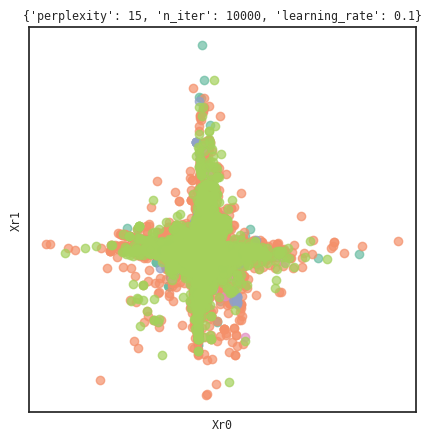

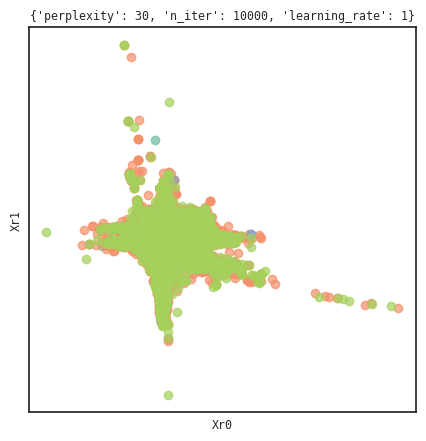

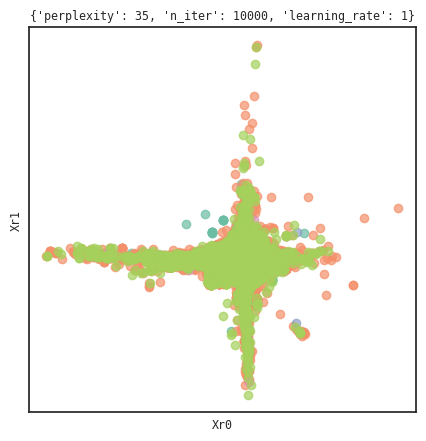

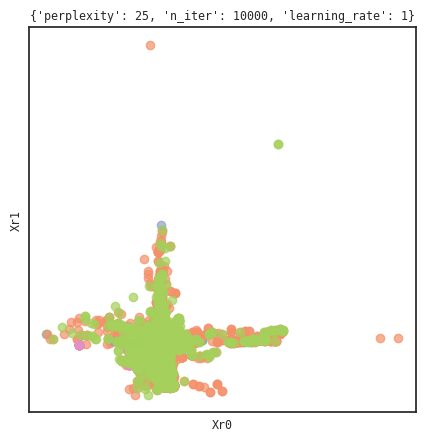

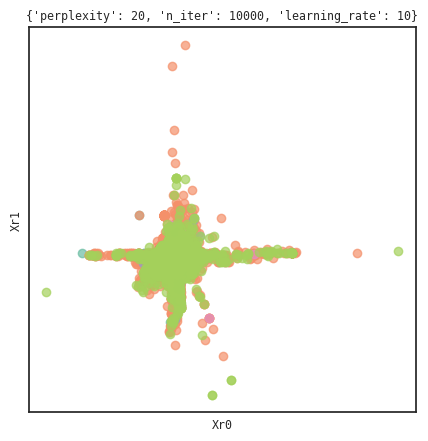

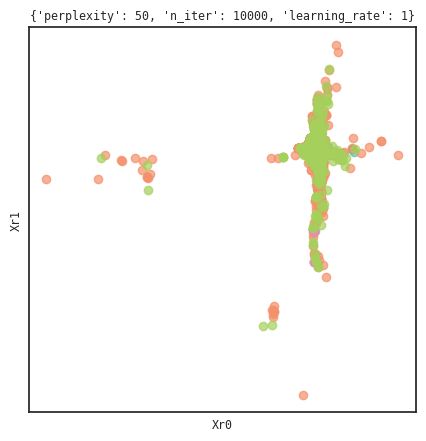

In [4]:
tf_cluster_coordinate_input=tf_compressed_thin.map_blocks(cp.asarray, dtype='f4').compute()

t_clusterer_options=dict(
  perplexity=[5*q for q in range(2,11)],
  n_iter=[10**q for q in range(4,5)],
  learning_rate=[10**q for q in range(-1,2)],
)

tf_cluster_label_normal=data_processed.reviewType.to_numpy(dtype='u4')

tf_cluster_coordinate_normal=cluster_aggregated(
  tf_cluster_coordinate_input,
  tf_cluster_label_normal,
  clusterer_options=t_clusterer_options,
  clusterer_options_size=6,
)